In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense
from keras.datasets import mnist
import matplotlib.pyplot as plt

### Problem statement:

- use a neural network to recognize two handwritten digits, zero and one (binary class.)


In [2]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

__int8__

is an unsigned 8-bit integer data type that stores whole numbers ranging from 0 to 255 (
). It is used for memory efficiency, requiring only 1 byte (8 bits) of storage, and is commonly used for representing pixel values, binary data

In [3]:
X_train = X_train/255
X_test = X_test/255

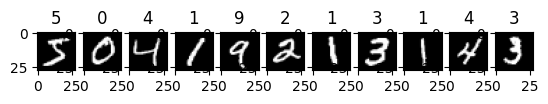

In [4]:
fig, ax = plt.subplots(1,11)
for i in range(0,11):
    ax[i].imshow(X_train[i],cmap='grey')
    ax[i].set_title(y_train[i])
    
    

In [5]:
X_train.shape[0:]

(60000, 28, 28)

In [6]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


Keras model:

input layer - > ignore sample size - > batches -> None

Input shape takes only the pixel x pixel , and stores it in the flattened array.

In [7]:
model_lr = tf.keras.models.Sequential(
[   tf.keras.layers.Input(shape=X_train.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation='softmax')
]

)

model_lr.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
model_lr.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

#### Outputshape == **NONE**

Inside keras, it does not care about the input shape, because it performs operation on batches.

In [8]:
#model_lr.fit(X_train,y_train)

### (32,), output.shape=(32, 10)

first shape - > Represents the y_train dimension and it has (600000,) 
**32** - number of batch size

In order to have matching dimension, I can go for 2 options

1) use one hot encoder for y_train

2) use the sparse activation function

In [9]:
y_one_hot = tf.one_hot(y_train,10)
model_lr.fit(X_train,y_one_hot)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.8779 - loss: 0.4673


In [10]:
model_lr.fit(X_train,y_one_hot)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9165 - loss: 0.3031


##### Subsequent calling of the model fit improves it's accuracy / decrases loss as expected


In [28]:
history_lr = model_lr.fit(X_train,y_one_hot,epochs=10,batch_size=128,validation_split=.2,verbose=False)

In [15]:
y_pred = model_lr.predict(X_test)
y_pred.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step


(10000, 10)

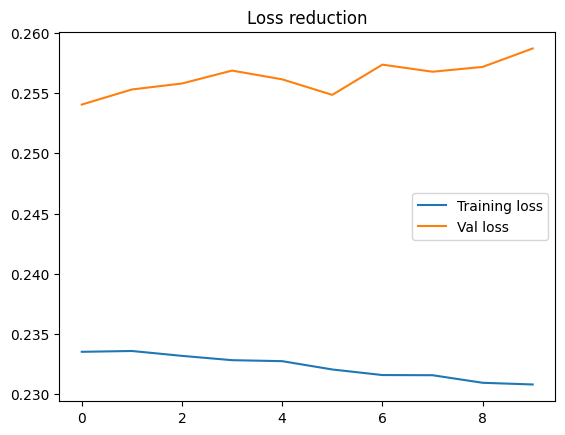

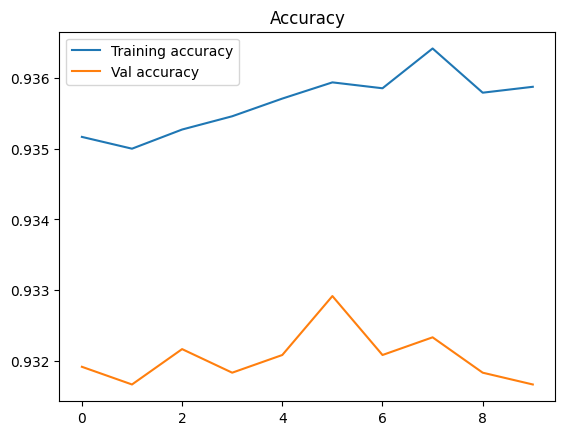

In [36]:
history_lr.history
plt.plot(history_lr.history['loss'],label='Training loss')
plt.plot(history_lr.history['val_loss'],label='Val loss')
plt.title('Loss reduction')
plt.legend()
plt.show()

plt.plot(history_lr.history['accuracy'],label='Training accuracy')
plt.plot(history_lr.history['val_accuracy'],label='Val accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [38]:
probs = model_lr.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [51]:
print(probs)
max_pred = np.argmax(probs,axis=1)


[[1.8181591e-08 2.1473407e-14 6.3221506e-08 3.9300215e-03 9.4608872e-08
  1.0589075e-05 4.1218673e-15 9.9578673e-01 7.2630860e-06 2.6520900e-04]
 [1.4491750e-05 1.0032420e-05 9.9657506e-01 7.7445560e-07 3.0856897e-17
  2.1349174e-04 3.1769597e-03 8.1912918e-23 9.2049122e-06 7.4122343e-20]
 [4.3879297e-07 9.9105495e-01 5.6044771e-03 7.6359953e-04 7.0953167e-05
  4.0014120e-04 3.6126105e-04 2.1903474e-05 1.5981412e-03 1.2411008e-04]
 [9.9994588e-01 6.3510386e-12 1.1968212e-05 4.6860481e-07 1.2951492e-08
  5.1237253e-06 3.1096126e-05 2.8806389e-06 1.0287202e-06 1.5488540e-06]
 [4.1347637e-04 3.3022129e-08 1.2665670e-03 8.4600515e-06 9.7728753e-01
  3.1247691e-05 9.7622129e-04 1.9659158e-03 1.9080812e-03 1.6142484e-02]]


7 ---> [1.8181591e-08 2.1473407e-14 6.3221506e-08 3.9300215e-03 9.4608872e-08
 1.0589075e-05 4.1218673e-15 9.9578673e-01 7.2630860e-06 2.6520900e-04]


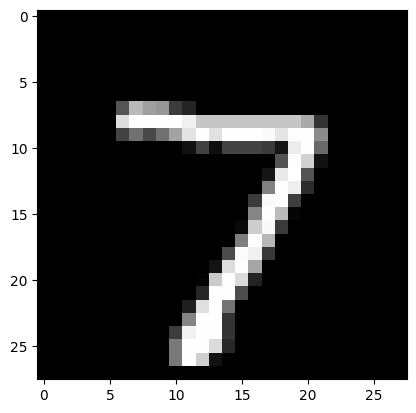

2 ---> [1.4491750e-05 1.0032420e-05 9.9657506e-01 7.7445560e-07 3.0856897e-17
 2.1349174e-04 3.1769597e-03 8.1912918e-23 9.2049122e-06 7.4122343e-20]


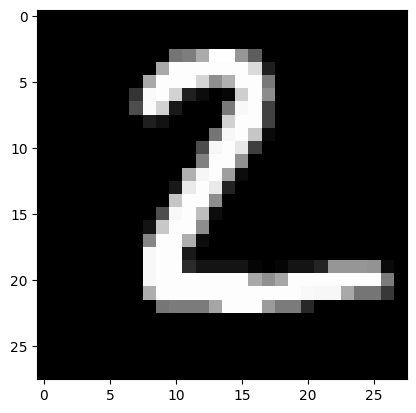

1 ---> [4.3879297e-07 9.9105495e-01 5.6044771e-03 7.6359953e-04 7.0953167e-05
 4.0014120e-04 3.6126105e-04 2.1903474e-05 1.5981412e-03 1.2411008e-04]


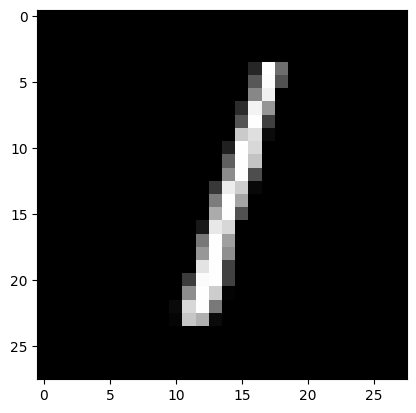

0 ---> [9.9994588e-01 6.3510386e-12 1.1968212e-05 4.6860481e-07 1.2951492e-08
 5.1237253e-06 3.1096126e-05 2.8806389e-06 1.0287202e-06 1.5488540e-06]


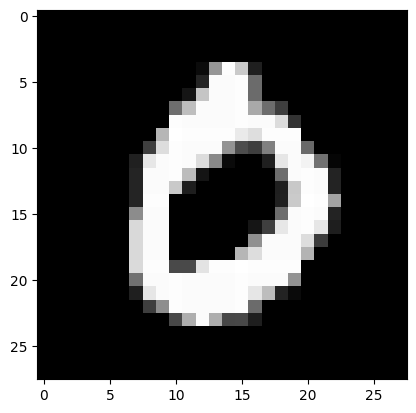

4 ---> [4.1347637e-04 3.3022129e-08 1.2665670e-03 8.4600515e-06 9.7728753e-01
 3.1247691e-05 9.7622129e-04 1.9659158e-03 1.9080812e-03 1.6142484e-02]


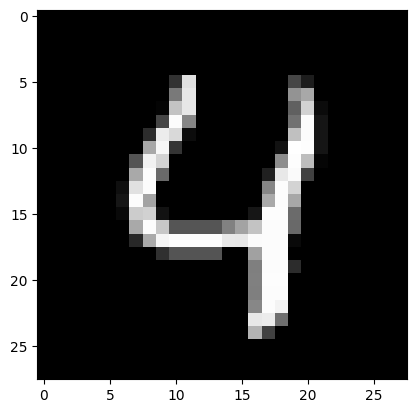

In [66]:
plt.subplots()
for i in range(5):
    print(max_pred[i], '--->', probs[i])
    plt.imshow(X_test[i],cmap='grey')
    plt.show()

### Multilayer perceptron

In [73]:
model_mp = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='sigmoid'),
    tf.keras.layers.Dense(32,activation='sigmoid'),
    tf.keras.layers.Dense(10,activation='sigmoid')
])

In [74]:
model_mp.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [75]:
history_mp = model_mp.fit(X_train,y_train,epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8632 - loss: 0.6206
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9398 - loss: 0.2125
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9558 - loss: 0.1548
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9651 - loss: 0.1224
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9708 - loss: 0.1003
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9755 - loss: 0.0854
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9791 - loss: 0.0728
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0636
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9843 - loss: 0.0555
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9866 - loss: 0.0487
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9883 - loss: 0.0424
Epoch 12/15
1875/1875 ━━━━━━━━